# 一些随便写的笔记内容

## 显示OCR结果并给出相应图片

ns = [] for i in if i % 11 == rarge(n% or '% 3 0: ns_ 5 I ans 0 for € in S: ans += (C SS '7') return ans ns)  e glg


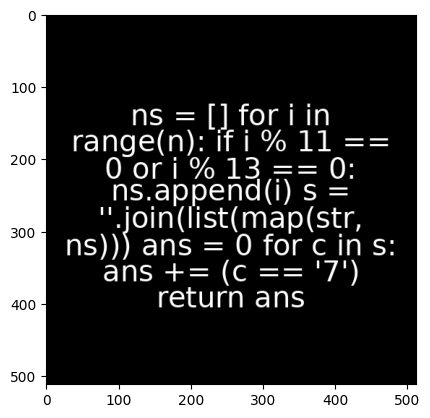

In [31]:
import json
import matplotlib.pyplot as plt
from PIL import Image
import os
label_image_dir = "/hongbojiang/datasets/VGU_benchmark/label_images/VGU"
with open("/hongbojiang/workdirs/VGU_OCR/labels.json", 'r') as f:
    ocr_results = json.load(f)
idx = 5
ocr_info = ocr_results['samples'][str(idx)]
print(ocr_info['text'])
plt.imshow(Image.open(os.path.join(label_image_dir, f"{idx}.png")))

comouet tne hesiten FUICTION Colhmnloer:,or tlher he oiget n nngneps tnrniues, ahasr tthuqtthamn iz alteessn line rgengeoser as vandlslile it fit $npinrs-,Ac s Tlhn N jrihess  hres in rhf eressrh_ eipera - PMI LIn Pliszuzs 3 (8 ti1sL 1arren 6 Fiz [Uitinat; 3 8 Filz-Zyhner SASS ? FizGuri l88-I0. In in 8


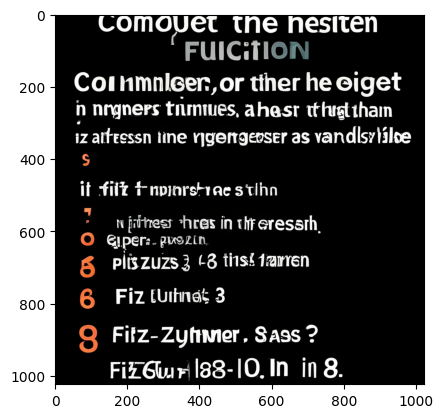

In [32]:
label_image_dir = "/hongbojiang/workdirs/VGU/BLIP3o"
with open("/hongbojiang/workdirs/VGU_OCR/BLIP3o.json", 'r') as f:
    ocr_results = json.load(f)
idx = 5
ocr_info = ocr_results['samples'][str(idx)]
print(ocr_info['text'])
plt.imshow(Image.open(os.path.join(label_image_dir, f"{idx}.png")))

## 试一试paddleocr

In [1]:
from paddleocr import PaddleOCR
# 初始化 PaddleOCR 实例
ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False)

# 对示例图像执行 OCR 推理 
result = ocr.predict(
    input="/hongbojiang/datasets/VGU_benchmark/label_images/VGU/0.png")
    
# 可视化结果并保存 json 结果
# for res in result:
#     res.save_to_json("output")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


In [8]:
' '.join(result[0]['rec_texts']),result[0].keys()

('%age Composition = C 84 %andH_16 % El-MS: m/z = 100,71, 57,43',
 dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes']))

In [26]:
result[0]['rec_scores']

[0.9866086840629578,
 0.9053856730461121,
 0.8844366073608398,
 0.9969722628593445]

## visualize VGU output

/tmp/ipykernel_1485502/2136976891.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


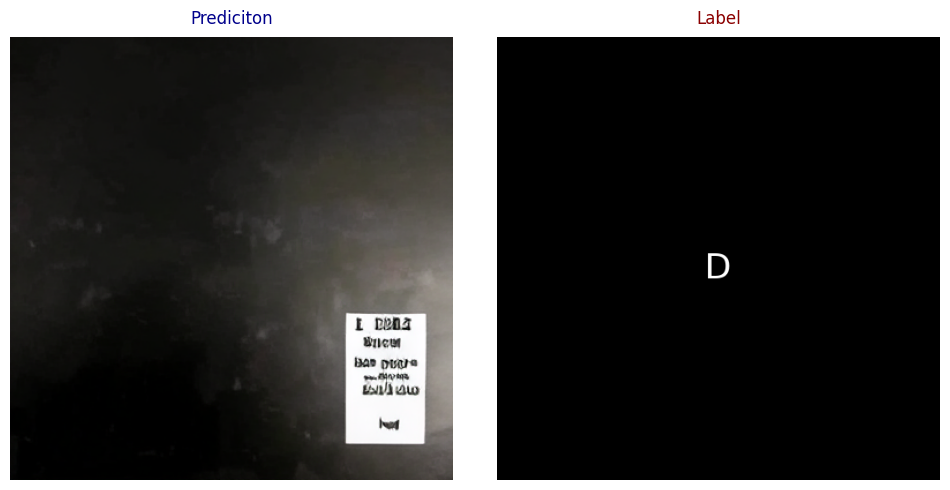

Question:
Controlling for inflation and PPP-adjustment, about how much did GDP per capita increase from 1950 to 2016 in South Korea? Please select the letter corresponding to the answer you believe to be correct from the options below.
(A)by 4 fold
(B)by 8 fold
(C)by 16 fold
(D)by 32 fold
Answer
D


In [92]:
import pandas as pd
import os

# model_name = 'LongCat'
# model_name = 'Qwen-Image'
# model_name = 'UniLIP'
# model_name = 'Janus'

idx=12
task_name = "VGU"
output_dir = "/hongbojiang/workdirs"
label_image_dir = "/hongbojiang/datasets/VGU_benchmark/label_images"
anno_dir = "/hongbojiang/datasets/VGU_benchmark/annotations"

if task_name=="VGU":
    anno_path = os.path.join(anno_dir, "TGU.csv") 
else:
    anno_path = os.path.join(anno_dir, f"{task_name}.csv") 
task_label_dir = os.path.join(label_image_dir, task_name)
task_output_dir = os.path.join(output_dir, task_name)
anno_df = pd.read_csv(anno_path)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import numpy as np


# 打开并调整图片大小
label_img_path = os.path.join(task_label_dir,f'{idx}.png')
prediction_img_path = os.path.join(task_output_dir, model_name, f'{idx}.png')
# 创建图形和GridSpec布局
fig = plt.figure(figsize=(12, 6))

# 使用GridSpec创建1行2列的布局，调整宽度比例和间距
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.1)

# 读取两张图片（请替换为你的图片路径）
img1 = Image.open(prediction_img_path)  # 替换为第一张图片路径
img2 = Image.open(label_img_path)  # 替换为第二张图片路径

# 将PIL图像转换为numpy数组
img1_array = np.array(img1)
img2_array = np.array(img2)

# 创建两个子图
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# 在左侧子图显示第一张图片
ax1.imshow(img1_array)
ax1.axis('off')  # 隐藏坐标轴

# 在右侧子图显示第二张图片
ax2.imshow(img2_array)
ax2.axis('off')  # 隐藏坐标轴

# 添加caption（标题）
ax1.set_title("Prediciton", 
              fontsize=12, pad=10, color='darkblue')
ax2.set_title("Label", 
              fontsize=12, pad=10, color='darkred')

# 自动调整布局，确保caption不重叠
plt.tight_layout()

# 显示图形
plt.show()
if task_name=="VGU":
    print("Question:")
    print(anno_df['question'][idx])
    print("Answer")
    print(anno_df['answer'][idx])
else:
    print("Caption:")
    print(anno_df['caption'][idx])

## 检查一下llm judge结果文件的完整性

首先看是不是llm judge生成的json文件是足够数量的，VGU为2164，Render为665。

In [4]:
# VGU
import os, json
import pandas as pd

MODELS_TO_EVALUATE = [
    "BLIP3o",
    "Janus",
    "JanusFlow", 
    "Show-o",
    "UniLIP",
    "LongCat",
    "Qwen-Image",
    "VGT"
]

for model_name in MODELS_TO_EVALUATE:
    vgu_df = pd.read_csv("/hongbojiang/datasets/VGU_benchmark/annotations/TGU.csv")
    fp = f"/hongbojiang/workdirs/COMSC_llm_judge/VGU/{model_name}.json"

    with open(fp, 'r') as f:
        result_dict = json.load(f)
    # 1.检查数目
    print(len(result_dict))
    # 2.检查是否和anno一一对应
    result_qs = [i['question'] for i in result_dict]
    anno_qs = vgu_df['question'].tolist()
    print(result_qs==anno_qs)

2164
True
2164
True
2164
True
2164
True
2164
True
2164
True
2164
True
2164
True


In [5]:
# Render
for model_name in MODELS_TO_EVALUATE:
    render_df = pd.read_csv("/hongbojiang/datasets/VGU_benchmark/annotations/T2I_Render.csv")
    fp = f"/hongbojiang/workdirs/COMSC_llm_judge/Render/{model_name}.json"

    with open(fp, 'r') as f:
        result_dict = json.load(f)
    # 1.检查数目
    print(len(result_dict))
    # 2.检查是否和anno一一对应
    result_qs = [i['question'] for i in result_dict]
    anno_qs = render_df['caption'].tolist()
    print(result_qs==anno_qs)

665
True
665
True
665
True
665
True
665
True
665
True
600
False
665
True
